# Song Classification
Exploratory data analysis on a Spotify tracks dataset. Evaluating regressor performance and determining the best attributes to use for song popularity prediction.

In [473]:
# imports
import importlib
import numpy as np
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, SGDRegressor

import utils
import plot_utils
importlib.reload(utils)
importlib.reload(plot_utils)

<module 'plot_utils' from '/home/Funsies/SpotifyTracksEDA/plot_utils.py'>

## Data Preparation
### A Look at the Dataset
Data source: https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset    
TODO description of attributes  

### Data Cleaning
Dropped the track id and track name as these are not useful in predictive tasks.  
For histogram generation: converted song duration in ms to minutes, and dropped all entries that were longer than 12 minutes.

In [474]:
songs = pd.read_csv("input_data/dataset.csv")

drop_columns = ["Unnamed: 0", "track_id", "track_name"]
for col in drop_columns:
    songs.pop(col)

# TODO perform EDA tasks (check if data distribution is normal, etc.)
# TODO normalization is not necessary bc numerical values are already probabilities in a range from 0 to 1
# TODO curious to find out which albums by certain artists are their most popular?

### Exploratory Data Analysis
Using correlation matrix, histograms, scatterplots, and bar plots to view attribute relationships.

#### Correlation Matrix
I was hoping to find some correlations between attributes and popularity, but the strongest was a negative relationship with a correlation coefficient of -0.10 between popularity and instrumentalness. Of the correlations between popularity and other attributes, the lowest are duration_ms, energy, key, liveness and tempo.

Relationships of note:  
* r = -0.73 between energy and acousticness
* r = 0.76 between energy and loudness
* r = -0.59 between acousticness and loudness

Other notes: There may still be significant non-linear relationships between certain attributes and popularity.

<AxesSubplot:>

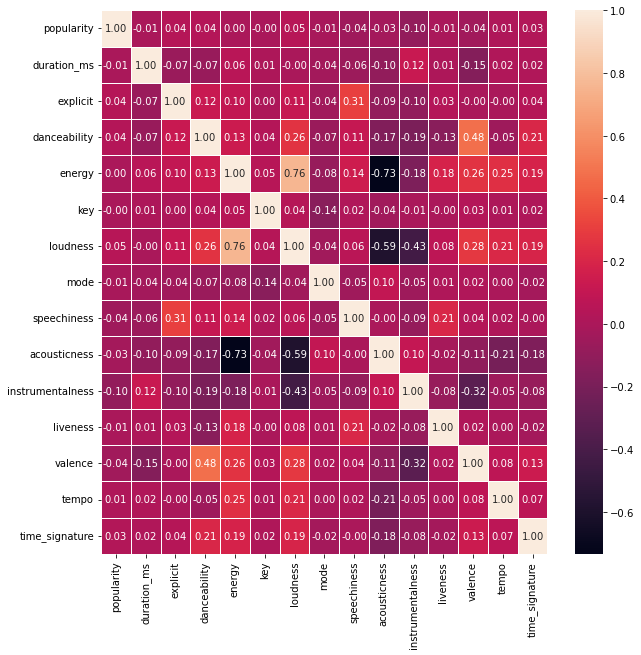

In [475]:
correlation_matrix = songs.corr()
fig, ax = plt.subplots(figsize=(10,10))
sn.heatmap(correlation_matrix, annot=True, linewidth=1, fmt=".2f")

#### Histograms

--- Prepping data for histograms ---
Num Songs >= 12 min: 301
Dropping 301 instances


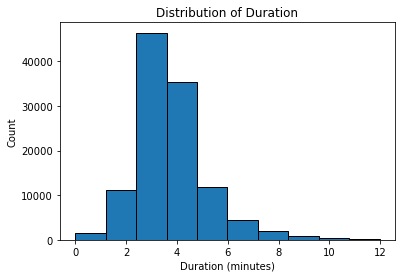

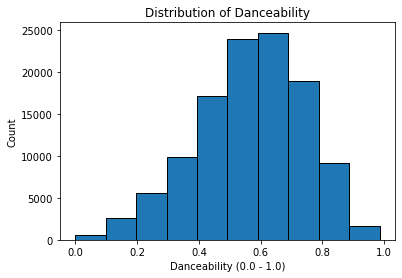

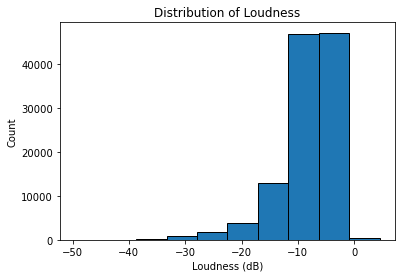

In [476]:
# data preparation
print("--- Prepping data for histograms ---")
duration_ms = songs["duration_ms"]
danceability = songs["danceability"]
loudness = songs["loudness"]
instrumentalness = songs["instrumentalness"]

# convert song length in ms to minutes
duration_minutes = [(ms / 1000) / 60 for ms in duration_ms]
# drop all songs 12 mins or longer to clean up histogram
count = 0
for time in duration_minutes:
    if time >= 12:
        count = count + 1
print("Num Songs >= 12 min:", count)
print("Dropping", count, "instances")
# drop last 301 songs
duration_minutes = sorted(duration_minutes)
duration_minutes = duration_minutes[:(((len(duration_minutes)) - 1) - 301)]

# generate histograms
plot_utils.make_histogram(duration_minutes, "Distribution of Duration", "Duration (minutes)", "Count")
plot_utils.make_histogram(danceability, "Distribution of Danceability", "Danceability (0.0 - 1.0)", "Count")
plot_utils.make_histogram(loudness, "Distribution of Loudness", "Loudness (dB)", "Count")

#### Bar Charts
Most popular genres?  
Also check top 50 most popular artists


--- Prepping data for bar charts ---
114 different genres
values ['acoustic', 'afrobeat', 'alt-rock', 'alternative', 'ambient', 'anime', 'black-metal', 'bluegrass', 'blues', 'brazil', 'breakbeat', 'british', 'cantopop', 'chicago-house', 'children', 'chill', 'classical', 'club', 'comedy', 'country', 'dance', 'dancehall', 'death-metal', 'deep-house', 'detroit-techno', 'disco', 'disney', 'drum-and-bass', 'dub', 'dubstep', 'edm', 'electro', 'electronic', 'emo', 'folk', 'forro', 'french', 'funk', 'garage', 'german', 'gospel', 'goth', 'grindcore', 'groove', 'grunge', 'guitar', 'happy', 'hard-rock', 'hardcore', 'hardstyle', 'heavy-metal', 'hip-hop', 'honky-tonk', 'house', 'idm', 'indian', 'indie', 'indie-pop', 'industrial', 'iranian', 'j-dance', 'j-idol', 'j-pop', 'j-rock', 'jazz', 'k-pop', 'kids', 'latin', 'latino', 'malay', 'mandopop', 'metal', 'metalcore', 'minimal-techno', 'mpb', 'new-age', 'opera', 'pagode', 'party', 'piano', 'pop', 'pop-film', 'power-pop', 'progressive-house', 'psych-r

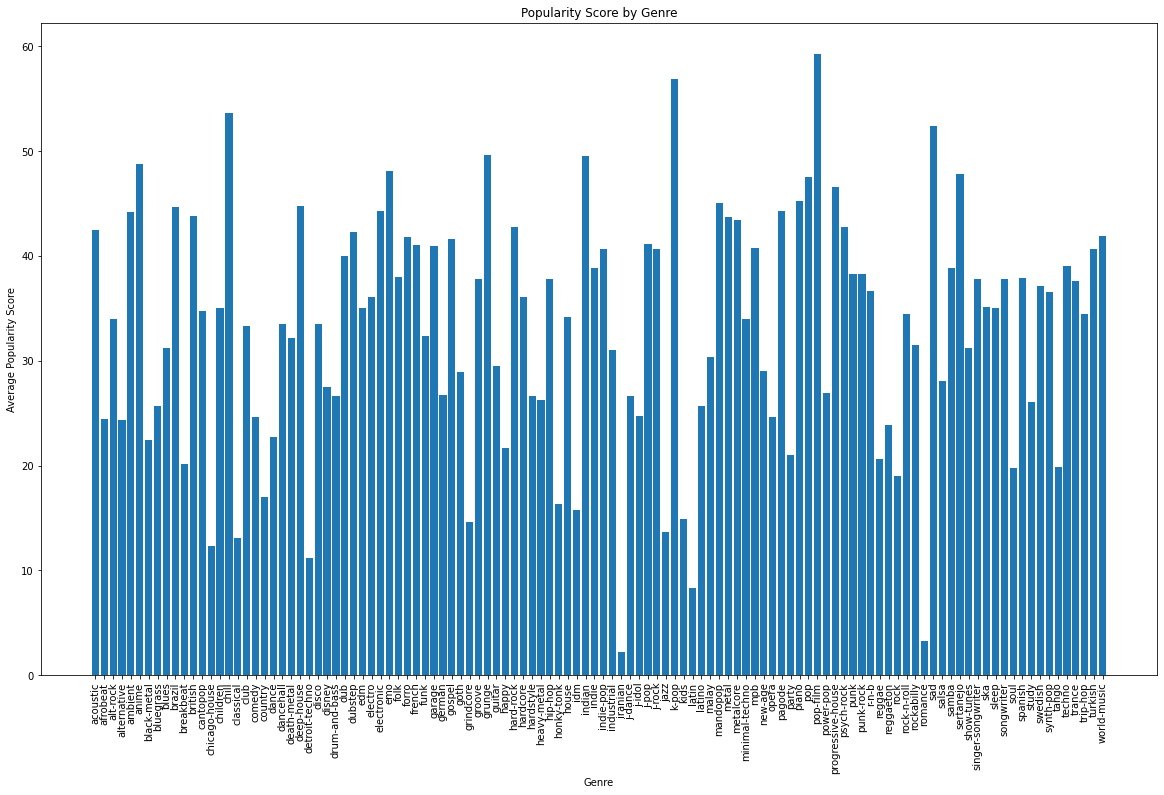

In [477]:
# data preparation
print("\n--- Prepping data for bar charts ---")
genre = songs["track_genre"]
genre_values, genre_counts = utils.get_frequencies(list(genre))
print(len(genre_values), "different genres")
print("values", genre_values)
print("counts", genre_counts)

# get average popularity score for each genre
avg_popularity = [0] * len(genre_values)
# sum popularity scores across all instances by genre
for idx, row in songs.iterrows():
    genre_index = genre_values.index(row["track_genre"])
    avg_popularity[genre_index] += row["popularity"]
# divide each sum to get average
for i, popularity_score in enumerate(avg_popularity):
    avg_popularity[i] = popularity_score / genre_counts[i]

print("Average popularities:", avg_popularity)

# TODO get top 50 artists and graph their popularity scores as well

# generate bar charts
plot_utils.make_bar_chart(genre_values, avg_popularity, "Popularity Score by Genre", "Genre", \
                          "Average Popularity Score", bar_labels=genre_values, rotation=90, figsize=(20,12))
# TODO clean this bar chart

#### Pie Charts
TODO generate pie chart of percentages of songs in each genre

#### Scatterplots

In [478]:
# generate scatterplots


## Train/Test Set Building
Using stratified k-fold cross validation (with k=10).

In [479]:
y = np.array(songs.pop("popularity"))
X = np.array(songs)

## Regressor Initialization
Comparing the performance of the KNN regressor, SGD regressor, and decision tree regressor, with a linear regressor as a baseline.

## Regressor Evaluation
Using the following metrics:
* Accuracy and error rate
* Precision, recall, and F1 measure